In [1]:
!pip install yfinance


Defaulting to user installation because normal site-packages is not writeable


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('fivethirtyeight')

In [3]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)

stock = 'SI=F'   # Silver Futures

stock_data = yf.download(stock, start=start, end=end)

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_11292\1453071018.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [4]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,SI=F,SI=F,SI=F,SI=F,SI=F
count,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000
mean,24.037563,24.260582,23.833448,24.057894,1798.560064
std,10.698386,11.045580,10.424390,10.766137,10111.557163
min,11.735000,12.205000,11.735000,12.070000,0.000000
25%,16.949500,17.019500,16.870001,16.932500,11.000000
50%,21.739000,21.870001,21.600000,21.746000,49.000000
75%,28.011000,28.235000,27.775001,28.010000,172.000000
max,115.080002,121.300003,112.735001,116.889999,170297.000000


In [12]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3771 entries, 2011-03-11 to 2026-03-11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, SI=F)   3771 non-null   float64
 1   (High, SI=F)    3771 non-null   float64
 2   (Low, SI=F)     3771 non-null   float64
 3   (Open, SI=F)    3771 non-null   float64
 4   (Volume, SI=F)  3771 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.8 KB


In [14]:
stock_data.columns


MultiIndex([( 'Close', 'SI=F'),
            (  'High', 'SI=F'),
            (   'Low', 'SI=F'),
            (  'Open', 'SI=F'),
            ('Volume', 'SI=F')],
           names=['Price', 'Ticker'])

In [18]:
closing_price = stock_data[['Close']]

In [20]:
closing_price["Close"]

Ticker,SI=F
Date,
2011-03-11,35.932999
2011-03-14,35.825001
2011-03-15,34.116001
2011-03-16,34.471001
2011-03-17,34.259998
...,...
2026-03-05,81.686996
2026-03-06,83.816002
2026-03-09,84.031998


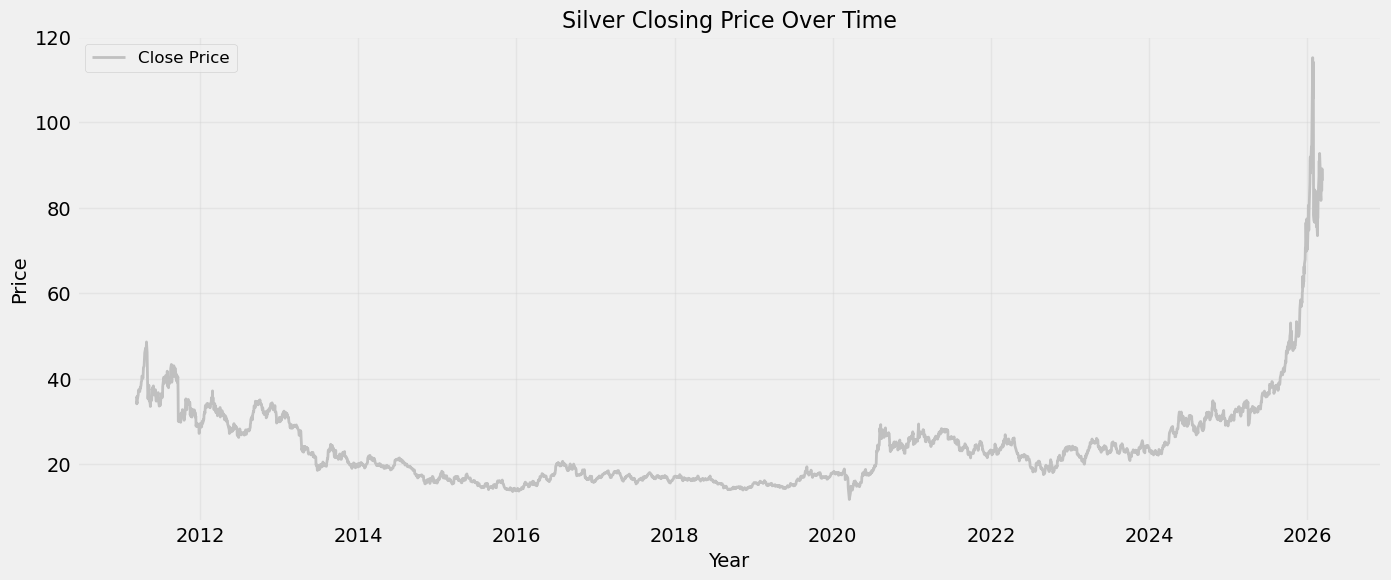

In [22]:
plt.figure(figsize=(15,6))
plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='silver', linewidth=2)

plt.title("Silver Closing Price Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [24]:
closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_11292\2942381381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_11292\2942381381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()


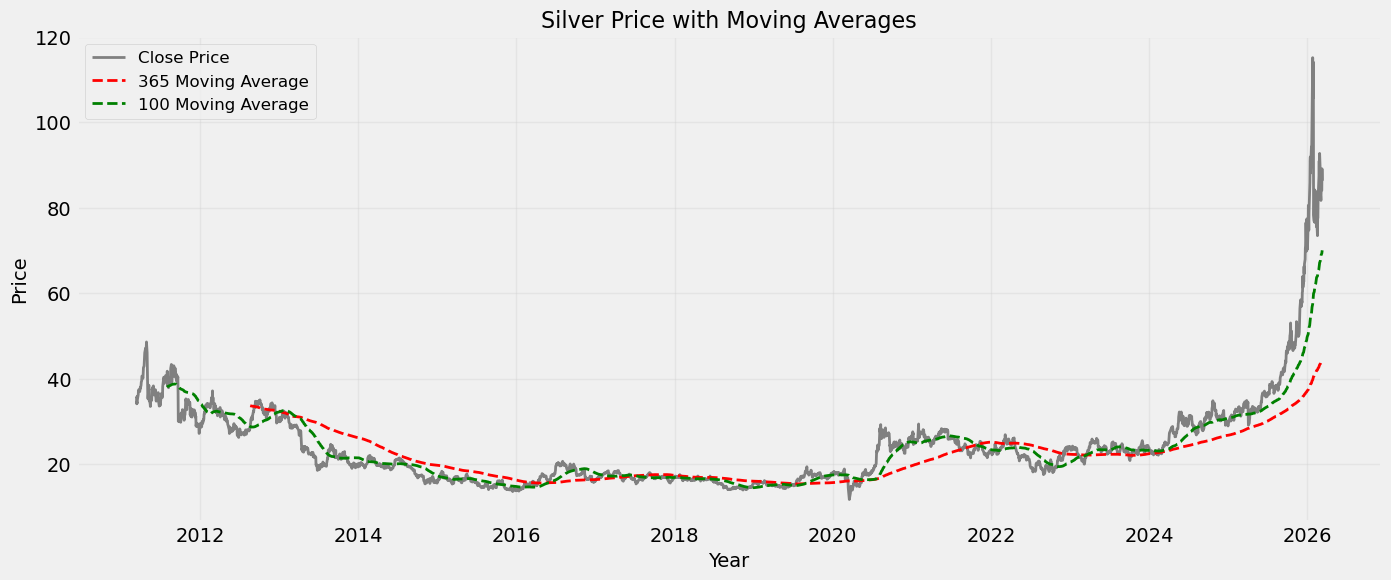

In [26]:
plt.figure(figsize=(15,6))

plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='gray', linewidth=2)
plt.plot(closing_price.index, closing_price['MA_365'], label='365 Moving Average', color='red', linestyle="--", linewidth=2)
plt.plot(closing_price.index, closing_price['MA_100'], label='100 Moving Average', color='green', linestyle="--", linewidth=2)

plt.title("Silver Price with Moving Averages", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [30]:
scaled_data

array([[0.23414774],
       [0.23310272],
       [0.21656588],
       ...,
       [0.69956937],
       [0.74844452],
       [0.72141855]])

In [32]:
len(scaled_data)

3771

In [34]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [35]:
x_data = []
y_data = []

base_days = 100

for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])

x_data = np.array(x_data)
y_data = np.array(y_data)

In [36]:
train_size = int(len(x_data)*0.9)

x_train, y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [40]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

C:\Users\Soham Rajapurkar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.fit(x_train, y_train, batch_size=5, epochs=10)

Epoch 1/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 78s 94ms/step - loss: 4.2474e-04
Epoch 2/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 68s 103ms/step - loss: 6.2780e-05
Epoch 3/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 54s 82ms/step - loss: 5.2726e-05
Epoch 4/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 45s 67ms/step - loss: 3.9316e-05
Epoch 5/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 80s 65ms/step - loss: 4.9149e-05
Epoch 6/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - loss: 3.6745e-05
Epoch 7/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - loss: 3.3566e-05
Epoch 8/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - loss: 3.2606e-05
Epoch 9/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - loss: 3.0470e-05
Epoch 10/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - loss: 4.4313e-05


In [43]:
prediction = model.predict(x_test)

inv_predictions = scaler.inverse_transform(prediction)
inverse_y_test = scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step


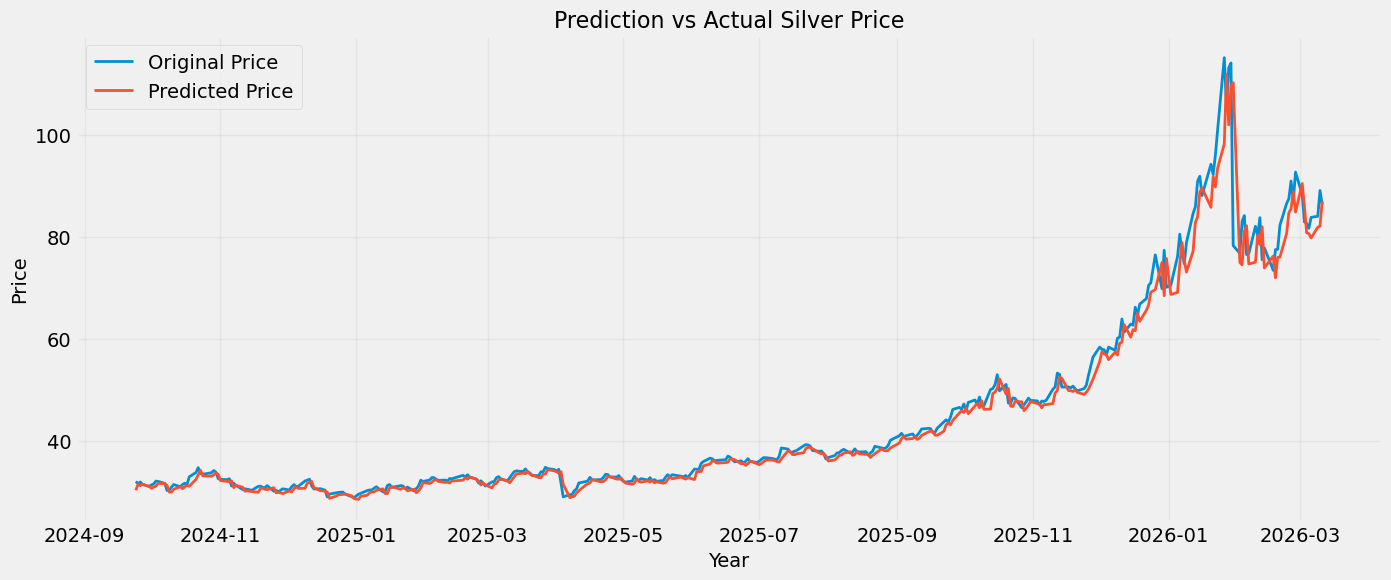

In [44]:
plotting_data = pd.DataFrame(
    {
        'Original': inverse_y_test.flatten(),
        'Prediction': inv_predictions.flatten(),
    },
    index = closing_price.index[train_size+base_days:]
)

plt.figure(figsize=(15,6))

plt.plot(plotting_data.index, plotting_data['Original'], label='Original Price', linewidth=2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label='Predicted Price', linewidth=2)

plt.title("Prediction vs Actual Silver Price", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [45]:
last_100 = scaled_data[-100:].reshape(1,-1,1)

future_predictions = []

for _ in range(10):
    
    next_day = model.predict(last_100)
    
    future_predictions.append(scaler.inverse_transform(next_day))
    
    last_100 = np.append(last_100[:,1:,:], next_day.reshape(1,1,-1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [46]:
future_predictions = np.array(future_predictions).flatten()

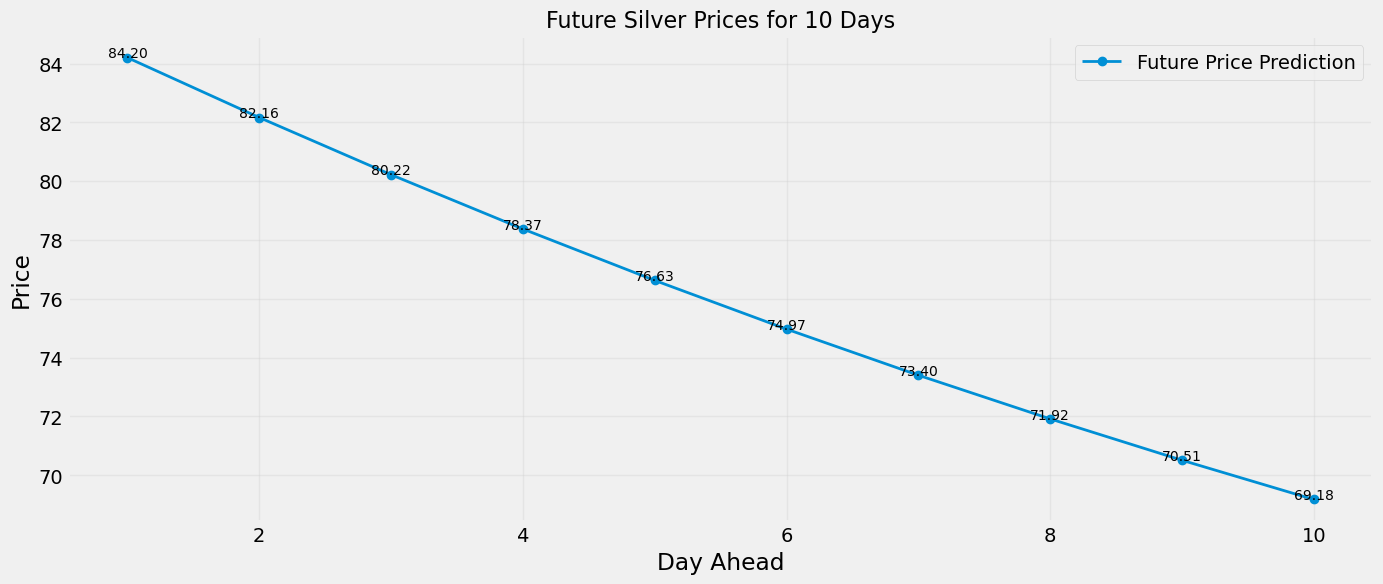

In [47]:
plt.figure(figsize=(15,6))

plt.plot(range(1,11), future_predictions, marker="o", label='Future Price Prediction', linewidth=2)

for i, val in enumerate(future_predictions):
    plt.text(i+1, val, f'{val:.2f}', fontsize=10, ha='center')

plt.title("Future Silver Prices for 10 Days", fontsize=16)
plt.xlabel("Day Ahead")
plt.ylabel("Price")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [48]:
model.save("silver_price_model.keras")

In [49]:
model.save("silver_price_model.keras")